# Severe_Toxic

In [ ]:
import pandas as pd
import numpy as np

data = pd.read_parquet("/Users/stephaniewright/Desktop/dense_engineered_train.parquet")

toxic = data["toxic"]
severe_toxic = data["severe_toxic"]
obscene = data["obscene"]
threat = data["threat"]
insult = data["insult"]
identity_hate = data["identity_hate"]

X_train = data.drop(
    columns=[
        "id",
        "toxic",
        "severe_toxic",
        "obscene",
        "threat",
        "insult",
        "identity_hate",
    ]
)

y_train = severe_toxic

from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=1234
)

from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight="balanced", y=y_tr)

np.float64(0.00880485802558109)

# Baseline Models

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

log = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, C=0.1, class_weight="balanced")),
    ]
)

mlp = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "model",
            MLPClassifier(
                hidden_layer_sizes=(100, 50),
                alpha=1e-4,
                learning_rate_init=1e-3,
                max_iter=200,
                early_stopping=True,
                random_state=1234,
            ),
        ),
    ]
)

rf = Pipeline(
    [
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=None,
                min_samples_split=2,
                min_samples_leaf=1,
                n_jobs=-1,
                random_state=1234,
                class_weight="balanced",
            ),
        )
    ]
)

hgb = Pipeline(
    [
        (
            "model",
            HistGradientBoostingClassifier(
                learning_rate=0.05,
                max_iter=200,
                max_leaf_nodes=31,
                min_samples_leaf=20,
                early_stopping=True,
                random_state=1234,
            ),
        )
    ]
)

models = {
    "Logistic Regression": log,
    "Random Forest": rf,
    "Hist Gradient Boosting": hgb,
    "Neural Networks": mlp,
}

# Baseline Results

In [ ]:
import time
from sklearn.metrics import average_precision_score, precision_recall_curve

results = {}

for name, model in models.items():

    start_train = time.time()
    if name == "Hist Gradient Boosting":
        model.fit(X_tr, y_tr, model__sample_weight=sample_weights)
    else:
        model.fit(X_tr, y_tr)
    train_time = time.time() - start_train

    start_pred = time.time()
    y_score = model.predict_proba(X_val)[:, 1]
    pred_time = time.time() - start_pred

    ap = average_precision_score(y_val, y_score)
    precision, recall, _ = precision_recall_curve(y_val, y_score)

    results[name] = {
        "model": model,
        "y_score": y_score,
        "ap": ap,
        "precision": precision,
        "recall": recall,
        "train_time": train_time,
        "pred_time": pred_time,
    }

    print(f"{name}:")
    print(f"  AP      = {ap:.4f}")
    print(f"  Train   = {train_time:.2f}")
    print(f"  Predict = {pred_time:.2f}")

Logistic Regression:
  AP      = 0.3592
  Train   = 0.47
  Predict = 0.01
Random Forest:
  AP      = 0.3304
  Train   = 9.14
  Predict = 0.10
Hist Gradient Boosting:
  AP      = 0.3635
  Train   = 1.65
  Predict = 0.04
Neural Networks:
  AP      = 0.3840
  Train   = 7.50
  Predict = 0.04


# Hyperparameter Tuning 

In [18]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1234)

In [ ]:
from sklearn.model_selection import GridSearchCV

log_grid = {
    "model__C": [0.001, 0.01, 0.1, 1, 10],
    "model__class_weight": [None, "balanced"],
}

log_search = GridSearchCV(
    estimator=log,
    param_grid=log_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

log_search.fit(X_tr, y_tr)
print(log_search.best_params_)
print(log_search.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'model__C': 10, 'model__class_weight': 'balanced'}
0.3788731194909075


In [15]:
from sklearn.model_selection import RandomizedSearchCV

mlp_dist = {
    "model__hidden_layer_sizes": [
        (32, 16),
        (64, 32),
        (100, 50),
        (128, 64),
        (128, 64, 32),
    ],  # 64, 32
    "model__alpha": [1e-5, 1e-4, 1e-3, 1e-2, 1e-1],  # 0.00001
    "model__learning_rate_init": [1e-4, 5e-4, 1e-3, 5e-3],  # 0.005
    "model__activation": ["relu", "tanh"],  # relu
    "model__batch_size": [64, 128],  # 64
}

mlp_search = RandomizedSearchCV(
    estimator=mlp,
    param_distributions=mlp_dist,
    n_iter=30,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=1234,
)

mlp_search.fit(X_tr, y_tr)  # 6 minutes
print(mlp_search.best_params_)
print(mlp_search.best_score_)  # 0.7323671646764351

Fitting 5 folds for each of 30 candidates, totalling 150 fits
{'model__learning_rate_init': 0.0001, 'model__hidden_layer_sizes': (128, 64), 'model__batch_size': 128, 'model__alpha': 0.0001, 'model__activation': 'tanh'}
0.3928249881210531


# Tuned Models

In [16]:
log = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, C=10, class_weight="balanced")),
    ]
)

mlp = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "model",
            MLPClassifier(
                hidden_layer_sizes=(128, 64),
                alpha=1e-4,
                batch_size=128,
                activation="tanh",
                learning_rate_init=1e-4,
                max_iter=200,
                early_stopping=True,
                random_state=1234,
            ),
        ),
    ]
)

models = {"Logistic Regression": log, "Neural Networks": mlp}

results = {}

for name, model in models.items():

    start_train = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - start_train

    start_pred = time.time()
    y_score = model.predict_proba(X_val)[:, 1]
    pred_time = time.time() - start_pred

    ap = average_precision_score(y_val, y_score)
    precision, recall, _ = precision_recall_curve(y_val, y_score)

    results[name] = {
        "model": model,
        "y_score": y_score,
        "ap": ap,
        "precision": precision,
        "recall": recall,
        "train_time": train_time,
        "pred_time": pred_time,
    }

    print(f"{name}:")
    print(f"  AP      = {ap:.4f}")
    print(f"  Train   = {train_time:.2f}")
    print(f"  Predict = {pred_time:.2f}")

Logistic Regression:
  AP      = 0.3612
  Train   = 0.49
  Predict = 0.01
Neural Networks:
  AP      = 0.3976
  Train   = 15.09
  Predict = 0.05


# Visualization 

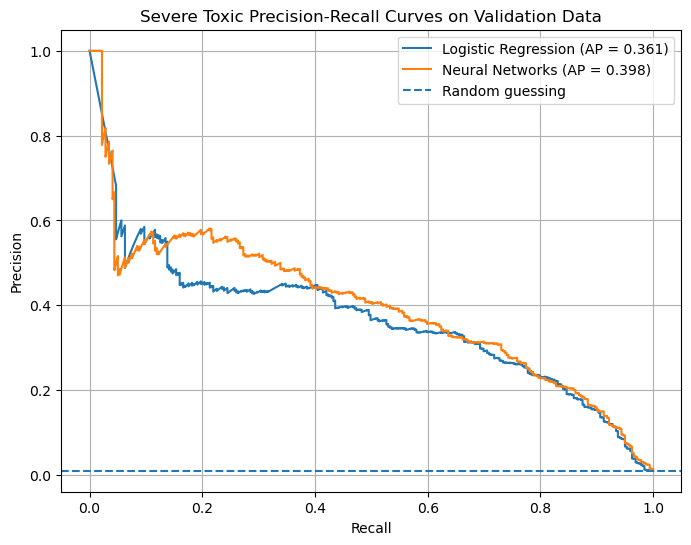

In [17]:
import matplotlib.pyplot as plt

baseline = y_val.mean()

plt.figure(figsize=(8, 6))

for name, res in results.items():
    plt.plot(res["recall"], res["precision"], label=f"{name} (AP = {res['ap']:.3f})")

plt.axhline(y=baseline, linestyle="--", label="Random guessing")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Severe Toxic Precision-Recall Curves on Validation Data")
plt.legend()
plt.grid(True)
plt.show()